In [5]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyterlab

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 11.9 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.1 MB 11.8 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 11.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 8.5 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 7.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 6.6 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.4 MB 2.8 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/12.4 MB 2.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/12.4 MB 2.8 MB/s eta 0:00:04
   ------ ------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tenure = time stayed 
* Low tenure → new customer → more chance to leave
* High tenure → old customer → less chance to leave
# churn = customer leaving the company
*  yes means left , NO means stayed


In [2]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
data.info()
data.describe()
data['Churn'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Churn
No     5174
Yes    1869
Name: count, dtype: int64

5174 customers had stayed and 1869 customers tends to leave 

# BASIC CLEANING


In [79]:

data.isnull().sum()
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)
data.head(4)

C:\Users\tufai\AppData\Local\Temp\ipykernel_21152\3237487177.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


# REMOVE DUPLICATES


In [69]:
# Check duplicates
data.duplicated().sum()

# Remove duplicates
data.drop_duplicates(inplace=True)

# CHECK UNIQUE VALUES

In [70]:
for col in data.columns:
    print(col, ":", data[col].nunique())

gender : 2
SeniorCitizen : 2
Partner : 2
Dependents : 2
tenure : 73
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
MonthlyCharges : 1585
TotalCharges : 6530
Churn : 2


# NOW DATA VISUALIZATION


* churn count

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (8,5)
sns.set_context("talk")   # bigger fonts
sns.set_palette("pastel")

# Gender vs Churn

 Churn is almost equal for both genders
 Gender is not a major factor in churn

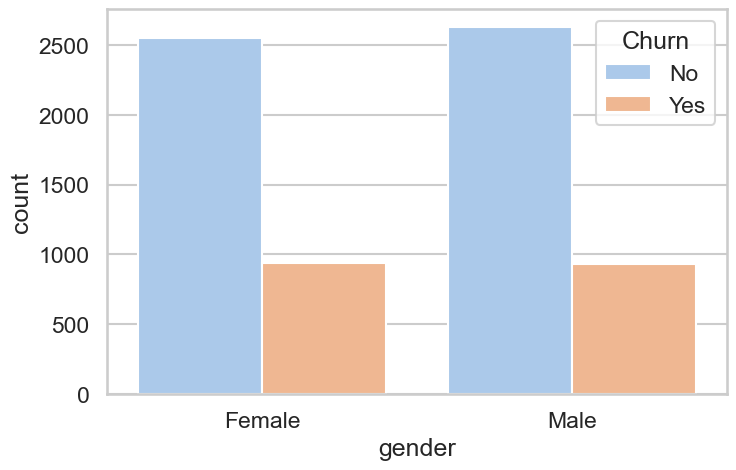

In [59]:
sns.countplot(x='gender', hue='Churn', data=data)
plt.show()

# BOXPLOT
* Customers with higher monthly charges tend to churn more
* Churn group has higher variation
* High pricing may be a key reason for churn

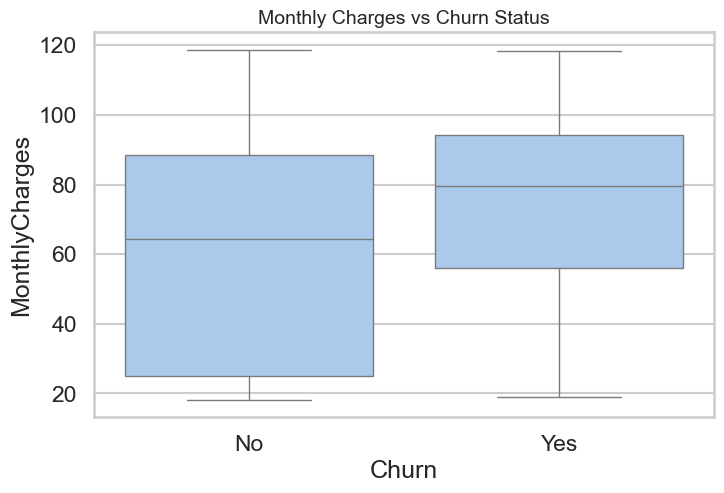

In [60]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("Monthly Charges vs Churn Status", fontsize=14)
plt.show()

# Churn Count Plot

Majority of customers are not churning
👉 But a significant portion has churned, which needs attention
👉 Company should focus on reducing churn rate

# Monthly Charges Distribution
Most customers pay moderate charges
 Few customers pay very high charges
 Pricing strategy may influence churn

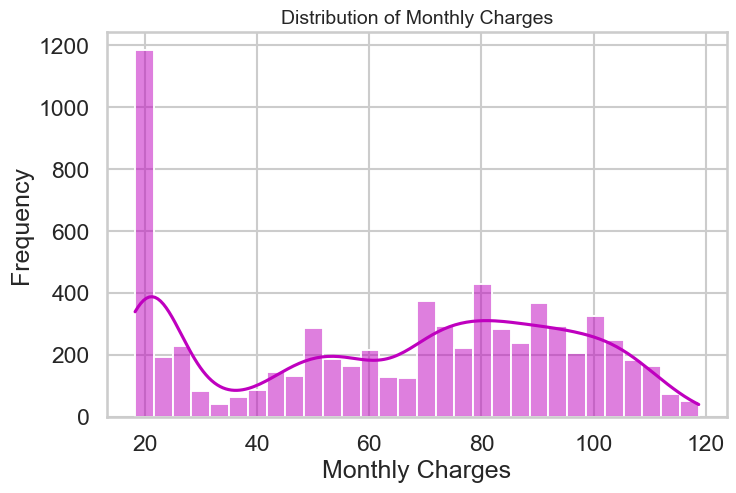

In [62]:
sns.histplot(data['MonthlyCharges'], bins=30, kde=True,color ='m')
plt.title("Distribution of Monthly Charges", fontsize=14)
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

# contract type vs churn
Month-to-month customers churn the most
* Long-term contracts reduce churn
* Offering yearly plans can improve retention

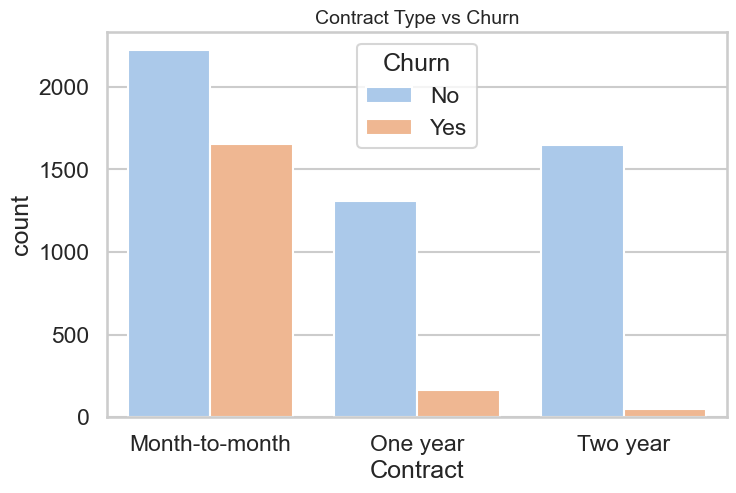

In [63]:
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title("Contract Type vs Churn", fontsize=14)
plt.xticks(rotation=0)
plt.show()

# Tenure vs churn
 * customers with low tenure churn more
* Long-term customers are more loyal
*  Early engagement is very important

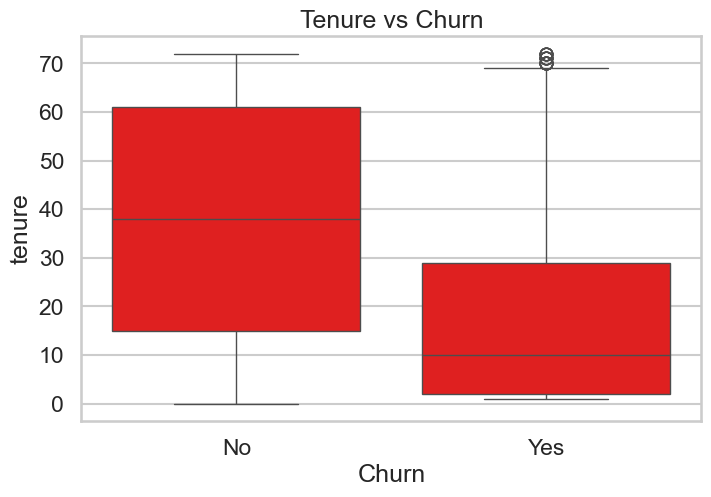

In [64]:
sns.boxplot(x='Churn', y='tenure', data=data,color='r')
plt.title("Tenure vs Churn")
plt.show()

# heatmap 
* Some features like MonthlyCharges & TotalCharges are correlated
* Helps understand relationships between variables
* Useful for model building

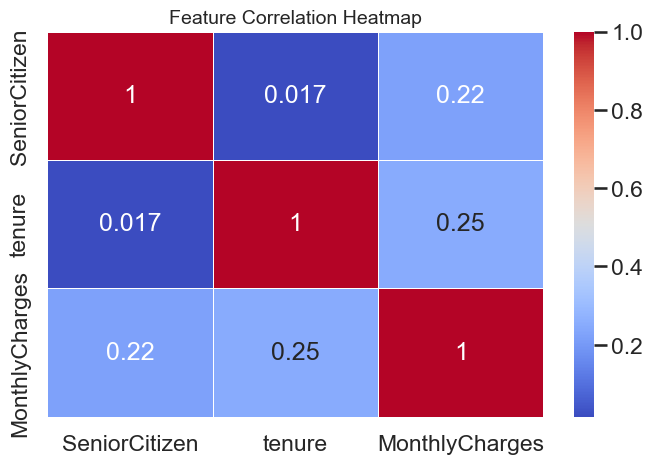

In [65]:
numeric_data = data.select_dtypes(include='number')

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

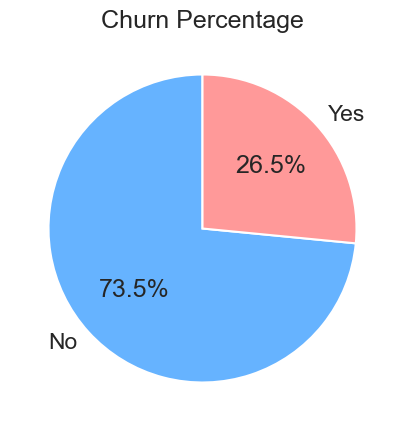

In [66]:
data['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff','#ff9999']
)
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

# Left graph:

Churn vs Non-Churn count

# Right graph:

Distribution of Monthly Charges

C:\Users\tufai\AppData\Local\Temp\ipykernel_21152\3592960120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=data, ax=axes[0], palette='Set2')


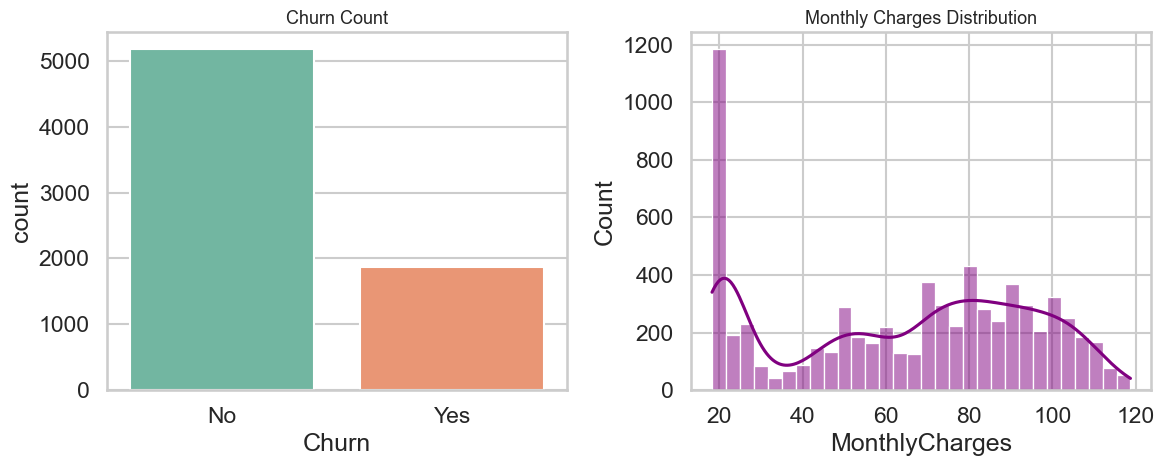

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(x='Churn', data=data, ax=axes[0], palette='Set2')
axes[0].set_title("Churn Count", fontsize=13)

sns.histplot(data['MonthlyCharges'], bins=30, kde=True, ax=axes[1], color='purple')
axes[1].set_title("Monthly Charges Distribution", fontsize=13)

plt.tight_layout()
plt.show()

# CONCLUSION 

 The majority of customers are not churned, but a noticeable number of customers have churned.

* Monthly charges are mostly concentrated in a moderate range, with fewer customers paying very high charges.

* This suggests that pricing distribution is balanced, but further analysis is needed to check if higher charges lead to churn.

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.show()

In [43]:
data ['MonthlyCharges'].min()

np.float64(18.25)

In [46]:
data = pd.get_dummies(data, drop_first=True)
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


In [49]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [50]:
X = data.drop('Churn_Yes', axis=1)
y = data['Churn_Yes']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\tufai\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8105039034776437
[[929 107]
 [160 213]]
              precision    recall  f1-score   support

       False       0.85      0.90      0.87      1036
        True       0.67      0.57      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [56]:
from sklearn.ensemble import RandomForestClassifier

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
pip install streamlit scikit-learn pandas numpy

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -------- ------------------------------- 1.8/9.1 MB 13.3 MB/s eta 0:00:01
   -------------------- ------------------- 4.7/9.1 MB 14.9 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/9.1 MB 11.2 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.1 MB 8.4 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/9.1 MB 7.3 MB/s eta 0:00:01
   --------------------------------- ------ 7.6/9.1 MB 6.7 MB/s eta 0:00:01
   ------------------------------------- -- 8.4/9.1 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.1 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 5.5 MB/s  0:00:01
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   -------------------------- ------------- 524.3/795.4 kB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 795.4/795.4 kB 2.8 MB/s  0:00:00
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [61]:
X.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF', 'customerID_0013-SMEOE',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str', length=7072)

In [62]:
import pickle

with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns, f)